In [8]:
import json
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import colorsys
from matplotlib.ticker import PercentFormatter, MultipleLocator


# ============================================================
# Generate vivid distinct colors
# ============================================================
def generate_vivid_colors(n):
    """
    Generate n visually distinct vivid colors using HSV space.
    """
    colors = []
    for i in range(n):
        hue = i / n
        saturation = 0.9
        value = 0.9
        rgb = colorsys.hsv_to_rgb(hue, saturation, value)
        colors.append(rgb)
    return colors


# ============================================================
# Plot multiple result folders (publication style)
# ============================================================
def plot_multiple_result_dirs(
    dir_list,
    chunk_sizes,
    max_event=650,
    title=None
):

    dir_list = [Path(d) for d in dir_list]

    # ---- chunk size handling ----
    if isinstance(chunk_sizes, int):
        chunk_sizes = [chunk_sizes] * len(dir_list)

    if len(chunk_sizes) != len(dir_list):
        raise ValueError("chunk_sizes must match number of directories")

    colors = generate_vivid_colors(len(dir_list))

    plt.figure(figsize=(10, 6))

    # ========================================================
    # Loop over result folders
    # ========================================================
    for dir_idx, result_dir in enumerate(dir_list):

        color = colors[dir_idx]
        chunk_size = chunk_sizes[dir_idx]
        dir_name = result_dir.name

        for json_file in result_dir.glob("*.json"):

            try:
                with open(json_file, "r") as f:
                    data = json.load(f)

                n = np.array(data["n"])
                avg_eer = np.array(data["avg_eer"])

                events = n * chunk_size

                mask = events <= max_event
                events = events[mask]
                avg_eer = avg_eer[mask]

                label = f"{dir_name} - {json_file.stem}"

                plt.plot(
                    events,
                    avg_eer,
                    linestyle="-",
                    linewidth=2.5,
                    marker="o",
                    markersize=5,
                    color=color,
                    alpha=0.95,
                    label=label
                )

            except Exception as e:
                print(f"[ERROR] Failed to process {json_file}: {e}")

    # ========================================================
    # Axis styling
    # ========================================================

    ax = plt.gca()

    # ----- Y axis start from 0 -----
    ax.set_ylim(bottom=0)

    # ----- tick every 0.5% -----
    ax.yaxis.set_major_locator(MultipleLocator(0.005))

    # ----- show percentage -----
    ax.yaxis.set_major_formatter(PercentFormatter(1.0))

    # ========================================================
    # Labels
    # ========================================================

    plt.xlabel("Events (n × chunk_size)", fontsize=13)
    plt.ylabel("Average EER (%)", fontsize=13)

    if title:
        plt.title(title, fontsize=14, weight="bold")
    else:
        plt.title("Multiple Result Comparison", fontsize=14, weight="bold")

    plt.grid(True, linestyle="--", alpha=0.4)

    plt.legend(
        fontsize=9,
        ncol=2,
        frameon=False
    )

    plt.tight_layout()
    plt.show()

## Balabit Protocol1

## CNN

**SRP**

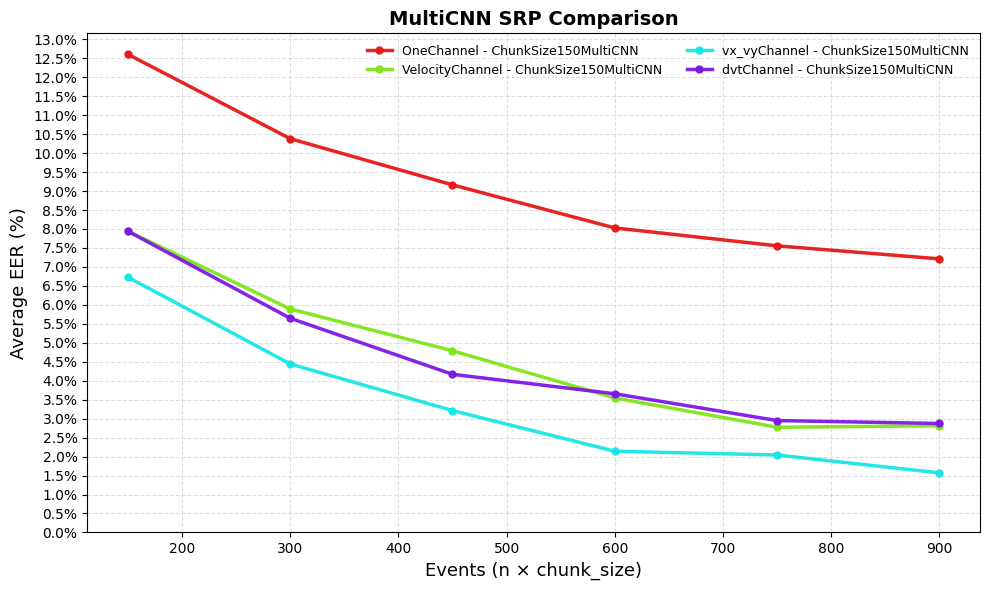

In [11]:
dir_list = ["Results/BalabitProtocol1/CNN/SRP/OneChannel","Results/BalabitProtocol1/CNN/SRP/VelocityChannel",
"Results/BalabitProtocol1/CNN/SRP/vx_vyChannel","Results/BalabitProtocol1/CNN/SRP/dvtChannel"]
plot_multiple_result_dirs(
    dir_list,
    max_event=1000,
    title="MultiCNN SRP Comparison",
    chunk_sizes=150
)

In [12]:
from statistics_things.wilcoxon_curve_compare import wilcoxon_curve_test

json_xy = "Results/BalabitProtocol1/CNN/SRP/per-userVelocityChannel/ChunkSize150MultiCNN.json"
json_cdf = "Results/BalabitProtocol1/CNN/SRP/per-uservx_vyChannel/ChunkSize150MultiCNN.json"

n_targets = [i+1 for i in range(4)]

df = wilcoxon_curve_test(
    json_xy,
    json_cdf,
    n_targets,
    label_a="Velocity",
    label_b="vx_vy",
    alpha=0.05
)

df

,Comparison,n,Users,Mean EER (Velocity),Mean EER (vx_vy),Absolute Diff (%),Wilcoxon p-value,Statistically Significant
0,Velocity vs vx_vy,1,10,7.94,6.73,1.21,0.105469,False
1,Velocity vs vx_vy,2,10,5.89,4.44,1.45,0.019531,True
2,Velocity vs vx_vy,3,10,4.79,3.21,1.58,0.011719,True
3,Velocity vs vx_vy,4,10,3.55,2.14,1.41,0.074219,False


**XYPlot**

## ViT

**SRP**

**XYPlot**

## Balabit Protocol2

## ChaoShen

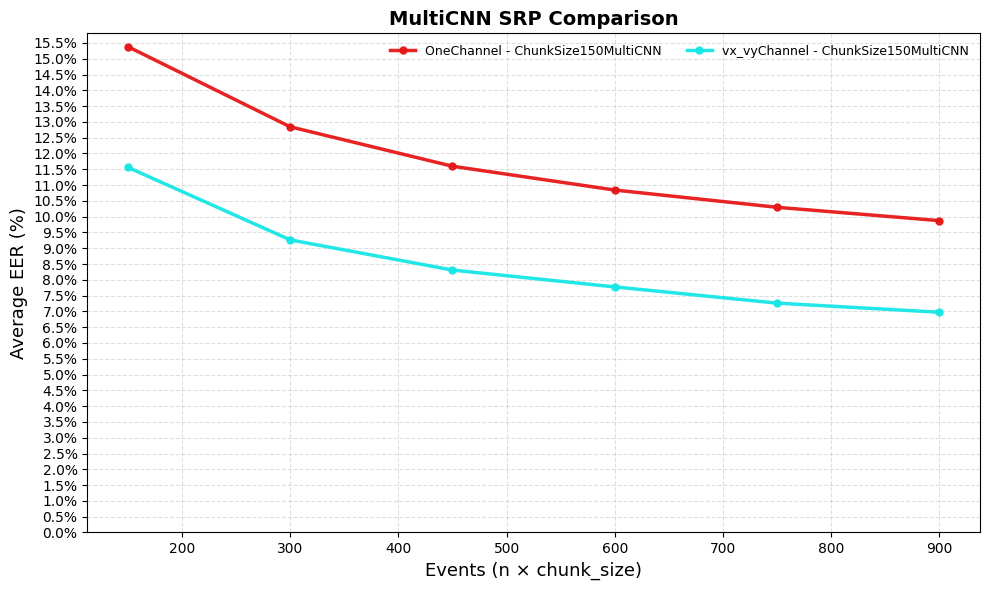

In [13]:
dir_list = ["Results/ChaoShen/CNN/SRP/OneChannel", "Results/ChaoShen/CNN/SRP/vx_vyChannel"]
plot_multiple_result_dirs(
    dir_list,
    max_event=1000,
    title="MultiCNN SRP Comparison",
    chunk_sizes=150
)

In [ ]:
from statistics_things.wilcoxon_curve_compare import wilcoxon_curve_test

json_xy = "Results/BalabitProtocol1/CNN/SRP/per-userVelocityChannel/ChunkSize150MultiCNN.json"
json_cdf = "Results/BalabitProtocol1/CNN/SRP/per-uservx_vyChannel/ChunkSize150MultiCNN.json"

n_targets = [i+1 for i in range(4)]

df = wilcoxon_curve_test(
    json_xy,
    json_cdf,
    n_targets,
    label_a="Velocity",
    label_b="vx_vy",
    alpha=0.05
)

df

## DFL